In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df=pd.read_csv("/content/final_dataset.csv")
df.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [12]:
df['emotion'].value_counts()

,count
emotion,
surprise,5363
neutral,5342
enthusiasm,5317
love,5255
relief,5236
sadness,5228
hate,5220
anger,5209
happiness,5196


In [13]:
df.isna().sum()

,0
text,0
emotion,0


In [14]:
df.dropna(inplace=True)

In [15]:
df.isna().sum()

,0
text,0
emotion,0


In [16]:
print(df.duplicated().sum())

7406


In [17]:
df.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [18]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate texts:", df["text"].duplicated().sum())
print("Conflicting texts:", (df.groupby("text")["emotion"].nunique() > 1).sum())

Total rows: 55955
Duplicate rows: 7406
Duplicate texts: 7422
Conflicting texts: 12


In [19]:

df = df.drop_duplicates()


In [20]:
conflict_counts = df.groupby("text")["emotion"].nunique()
conflict_texts = conflict_counts[conflict_counts > 1].index

In [21]:
conflict_df = df[df["text"].isin(conflict_texts)]

print(conflict_df.sort_values("text").to_string(index=False))

                                                                                                        text    emotion
BTW I STILL can't believe how Awesome the NEWJABBAKIDZ performance was...U in the masks..I screamed at my pc   surprise
BTW I STILL can't believe how Awesome the NEWJABBAKIDZ performance was...U in the masks..I screamed at my pc    sadness
                                                 FREE UNLIMITED RINGTONES!!! - - USA ONLY - Awesome 4 iphone  happiness
                                                 FREE UNLIMITED RINGTONES!!! - - USA ONLY - Awesome 4 iphone        fun
                                                 FREE UNLIMITED RINGTONES!!! - - USA ONLY - Awesome 4 iphone enthusiasm
                                                                                                Good morning  happiness
                                                                                                Good morning      empty
                  Hi I have uploaded 5 c

In [22]:
df.isna().sum()

,0
text,0
emotion,0


In [23]:
df = df[~df["text"].isin(conflict_texts)]

# 4. Check again
print("Rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate texts:", df["text"].duplicated().sum())
print(
    "Conflicting texts:",
    (df.groupby("text")["emotion"].nunique() > 1).sum()
)

Rows: 48521
Duplicate rows: 0
Duplicate texts: 0
Conflicting texts: 0


In [24]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [25]:
df["text"] = df["text"].astype(str)


df["clean_text"] = (
    df["text"]
    .str.lower()
    .str.replace(r'[^a-zA-Z\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [26]:
df.head()

,text,emotion,clean_text
0,i feel rather funny ending with so many dupes ...,fun,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result,surprise,i feel surprised by the result
2,i am officially feeling festive,neutral,i am officially feeling festive
3,i suddenly found myself standing before this w...,surprise,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...,enthusiasm,i look at the meager pile of food i purchased ...


In [27]:
print(df['text'][0])

i feel rather funny ending with so many dupes while i always prefer originals


In [28]:
print(df['clean_text'][0])

i feel rather funny ending with so many dupes while i always prefer originals


In [29]:
X=df["clean_text"]
y=df["emotion"]

In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english"
)

In [32]:
X_train = tfidf.fit_transform(X_train)


X_test = tfidf.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [34]:
from sklearn.metrics import accuracy_score,classification_report
y_pred=lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7660999484801648

Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.79      0.84       920
       empty       0.81      0.39      0.52       506
  enthusiasm       0.98      0.84      0.90       804
         fun       0.90      0.74      0.81       839
   happiness       0.71      0.71      0.71      1012
        hate       0.92      0.72      0.81       801
        love       0.91      0.90      0.90       901
     neutral       0.64      0.92      0.76      1061
      relief       0.93      0.79      0.85       895
     sadness       0.57      0.73      0.64      1027
    surprise       0.59      0.73      0.66       939

    accuracy                           0.77      9705
   macro avg       0.81      0.75      0.76      9705
weighted avg       0.79      0.77      0.77      9705



<Axes: >

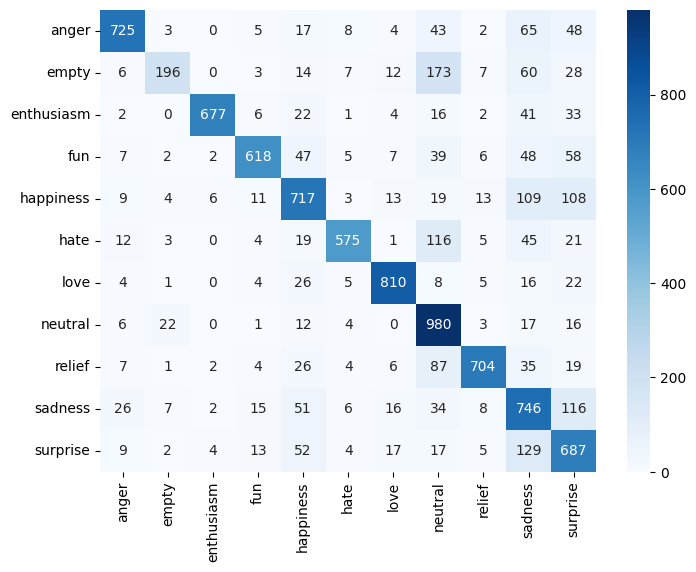

In [35]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lr.classes_, yticklabels=lr.classes_)

In [36]:
df["text"].size

48521

In [37]:
from sklearn.svm import LinearSVC
svc=LinearSVC(  )
svc.fit(X_train,y_train)


LinearSVC()

In [38]:
y_pred2=svc.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Accuracy: 0.7666151468315301

Classification Report:
              precision    recall  f1-score   support

       anger       0.84      0.83      0.84       920
       empty       0.69      0.49      0.57       506
  enthusiasm       0.95      0.87      0.91       804
         fun       0.85      0.78      0.81       839
   happiness       0.69      0.70      0.69      1012
        hate       0.88      0.73      0.80       801
        love       0.89      0.90      0.89       901
     neutral       0.66      0.86      0.74      1061
      relief       0.87      0.82      0.84       895
     sadness       0.62      0.67      0.64      1027
    surprise       0.64      0.69      0.67       939

    accuracy                           0.77      9705
   macro avg       0.78      0.76      0.76      9705
weighted avg       0.78      0.77      0.77      9705



In [39]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)


MultinomialNB()

In [40]:
y_pred3 = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Accuracy: 0.6427614631633178

Classification Report:
              precision    recall  f1-score   support

       anger       0.84      0.83      0.84       920
       empty       0.69      0.49      0.57       506
  enthusiasm       0.95      0.87      0.91       804
         fun       0.85      0.78      0.81       839
   happiness       0.69      0.70      0.69      1012
        hate       0.88      0.73      0.80       801
        love       0.89      0.90      0.89       901
     neutral       0.66      0.86      0.74      1061
      relief       0.87      0.82      0.84       895
     sadness       0.62      0.67      0.64      1027
    surprise       0.64      0.69      0.67       939

    accuracy                           0.77      9705
   macro avg       0.78      0.76      0.76      9705
weighted avg       0.78      0.77      0.77      9705



In [41]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [42]:
y_pred4=rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred4))

Accuracy: 0.7702215352910871

Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.80      0.84       920
       empty       0.62      0.39      0.48       506
  enthusiasm       0.97      0.86      0.91       804
         fun       0.88      0.76      0.82       839
   happiness       0.73      0.70      0.71      1012
        hate       0.93      0.72      0.81       801
        love       0.89      0.92      0.90       901
     neutral       0.65      0.93      0.77      1061
      relief       0.91      0.79      0.85       895
     sadness       0.59      0.71      0.64      1027
    surprise       0.65      0.72      0.68       939

    accuracy                           0.77      9705
   macro avg       0.79      0.75      0.76      9705
weighted avg       0.79      0.77      0.77      9705



In [43]:
text = input("Enter a sentence: ")

clean_text = (
    text.lower()
    .replace("!", "")
    .replace("?", "")
)

text_tfidf = tfidf.transform([clean_text])

prediction = lr.predict(text_tfidf)

print("Predicted emotion:", prediction[0])

Enter a sentence: i love ml
Predicted emotion: love


In [44]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [45]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=100),

    LSTM(128),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dense(11, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [47]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [48]:


history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.5162 - loss: 1.4666 - val_accuracy: 0.7718 - val_loss: 0.7757
Epoch 2/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8282 - loss: 0.5823 - val_accuracy: 0.8100 - val_loss: 0.6355
Epoch 3/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8822 - loss: 0.4005 - val_accuracy: 0.8196 - val_loss: 0.6403
Epoch 4/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9135 - loss: 0.2954 - val_accuracy: 0.8135 - val_loss: 0.7104
Epoch 5/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9295 - loss: 0.2418 - val_accuracy: 0.8100 - val_loss: 0.7711
Epoch 6/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9430 - loss: 0.1967 - val_accuracy: 0.8144 - val_loss: 0.7946
Epoch 7/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9526 - loss: 0.1596 - val_accuracy: 0.8136 - val_loss: 0.9496
Epoch 8/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9580 - loss: 0.1434 - val_acc

In [49]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [50]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8146 - loss: 0.9613
Test Loss: 0.9613384008407593
Test Accuracy: 0.8146316409111023


In [51]:
import numpy as np

y_pred_prob = model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.83      0.83      0.83       893
       empty       0.83      0.82      0.82       517
  enthusiasm       0.92      0.90      0.91       784
         fun       0.82      0.81      0.82       827
   happiness       0.70      0.73      0.71       992
        hate       0.94      0.90      0.92       812
        love       0.93      0.89      0.91       970
     neutral       0.85      0.91      0.88      1062
      relief       0.91      0.88      0.90       893
     sadness       0.63      0.62      0.63      1008
    surprise       0.68      0.69      0.69       947

    accuracy                           0.81      9705
   macro avg       0.82      0.82      0.82      9705
weighted avg       0.82      0.81      0.82      9705



early stopping


In [53]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [54]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9726 - loss: 0.0917 - val_accuracy: 0.8094 - val_loss: 1.1796
Epoch 2/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9757 - loss: 0.0816 - val_accuracy: 0.8091 - val_loss: 1.2397
Epoch 3/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9758 - loss: 0.0824 - val_accuracy: 0.8107 - val_loss: 1.1566
Epoch 4/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9780 - loss: 0.0720 - val_accuracy: 0.8099 - val_loss: 1.2427
Epoch 5/10
486/486 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9829 - loss: 0.0566 - val_accuracy: 0.8107 - val_loss: 1.3550


In [55]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Accuracy:", test_accuracy)

304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8134 - loss: 1.1022
Test Accuracy: 0.8133951425552368


In [56]:
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

       anger       0.82      0.80      0.81       893
       empty       0.83      0.83      0.83       517
  enthusiasm       0.91      0.90      0.91       784
         fun       0.85      0.81      0.83       827
   happiness       0.76      0.72      0.74       992
        hate       0.91      0.90      0.91       812
        love       0.90      0.91      0.90       970
     neutral       0.84      0.91      0.87      1062
      relief       0.93      0.89      0.91       893
     sadness       0.59      0.64      0.62      1008
    surprise       0.69      0.68      0.68       947

    accuracy                           0.81      9705
   macro avg       0.82      0.82      0.82      9705
weighted avg       0.82      0.81      0.81      9705



In [ ]:
text = input("Enter a sentence: ")

clean_text = (
    text.lower()
    .replace("!", "")
    .replace("?", "")
)

text_tfidf = tfidf.transform([clean_text])

prediction = model.predict(text_tfidf)

print("Predicted emotion:", prediction[0])